## 1. Moduls to Use

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# 2. Import Datasets

In [6]:
path_train = "D:\\iti\\HR Analytics_ Job Change of Data Scientists Dataset\\aug_train.csv"
path_test = "D:\\iti\\HR Analytics_ Job Change of Data Scientists Dataset\\aug_test.csv"
path_submission = "D:\\iti\\HR Analytics_ Job Change of Data Scientists Dataset\\sample_submission.csv"

In [7]:
df_train = pd.read_csv(path_train)
df_test = pd.read_csv(path_test)

In [8]:
#First 5 rows - Train

df_train.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [9]:
#First 5 rows - Test

df_test.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
0,32403,city_41,0.827,Male,Has relevent experience,Full time course,Graduate,STEM,9,<10,NaN,1,21
1,9858,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,5,NaN,Pvt Ltd,1,98
2,31806,city_21,0.624,Male,No relevent experience,no_enrollment,High School,NaN,<1,NaN,Pvt Ltd,never,15
3,27385,city_13,0.827,Male,Has relevent experience,no_enrollment,Masters,STEM,11,10/49,Pvt Ltd,1,39
4,27724,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,10000+,Pvt Ltd,>4,72


# 3. Exploratory Data Analysis

## 3.1 General analysis

In [10]:
df_train.dtypes

enrollee_id                 int64
city                       object
city_development_index    float64
gender                     object
relevent_experience        object
enrolled_university        object
education_level            object
major_discipline           object
experience                 object
company_size               object
company_type               object
last_new_job               object
training_hours              int64
target                    float64
dtype: object

In [11]:
#Columns (features) - Train

list(df_train.columns)

['enrollee_id',
 'city',
 'city_development_index',
 'gender',
 'relevent_experience',
 'enrolled_university',
 'education_level',
 'major_discipline',
 'experience',
 'company_size',
 'company_type',
 'last_new_job',
 'training_hours',
 'target']

In [12]:
#Columns (features) - Test

list(df_test.columns)

['enrollee_id',
 'city',
 'city_development_index',
 'gender',
 'relevent_experience',
 'enrolled_university',
 'education_level',
 'major_discipline',
 'experience',
 'company_size',
 'company_type',
 'last_new_job',
 'training_hours']

In [13]:
#Shape of the DataFrame - Train

df_train.shape

(19158, 14)

In [14]:
#Shape of the DataFrame - Test

df_test.shape

(2129, 13)

In [15]:
#Number of NaN per column

def percentage_nulls(df):

    number_nulls = pd.DataFrame(df.isnull().sum(),columns=['Total'])
    number_nulls['% nulls'] = round((number_nulls['Total'] / df.shape[0])*100,1)
    
    return number_nulls

In [16]:
#NaN for Train

percentage_nulls(df_train)

,Total,% nulls
enrollee_id,0,0.0
city,0,0.0
city_development_index,0,0.0
gender,4508,23.5
relevent_experience,0,0.0
enrolled_university,386,2.0
education_level,460,2.4
major_discipline,2813,14.7
experience,65,0.3
company_size,5938,31.0


In [17]:
#NaN for Test

percentage_nulls(df_test)

,Total,% nulls
enrollee_id,0,0.0
city,0,0.0
city_development_index,0,0.0
gender,508,23.9
relevent_experience,0,0.0
enrolled_university,31,1.5
education_level,52,2.4
major_discipline,312,14.7
experience,5,0.2
company_size,622,29.2


As seen in some columns there is a considerable amount of NaN.

The % are similar in master datasets (train and test)

## 3.2 Feature *'city'* - City code

In [18]:
#City - Train

city_train = df_train['city']
city_train.value_counts()

city
city_103    4355
city_21     2702
city_16     1533
city_114    1336
city_160     845
            ... 
city_111       3
city_129       3
city_121       3
city_140       1
city_171       1
Name: count, Length: 123, dtype: int64

In [19]:
#City - Test

city_test = df_test['city']
city_test.value_counts()

city
city_103    473
city_21     318
city_16     168
city_114    155
city_160    113
           ... 
city_117      1
city_157      1
city_180      1
city_84       1
city_78       1
Name: count, Length: 108, dtype: int64

it is observed that the cities are coded with a number and they are 123 different citys for Train and 108 for test

## 3.3 Feature *'city_ development _index'* -  Developement index of the city (scaled)

For more information: https://en.wikipedia.org/wiki/City_development_index

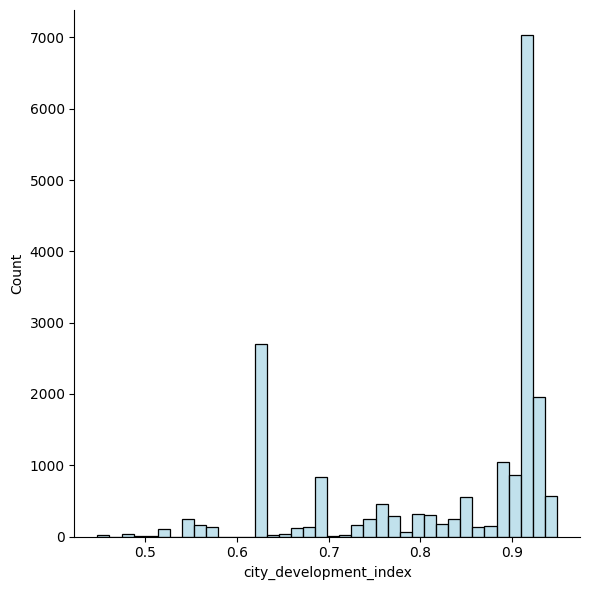

In [20]:
#Distribution city development index - Train

sns.displot(data=df_train, x='city_development_index',height=6,color = 'lightblue')

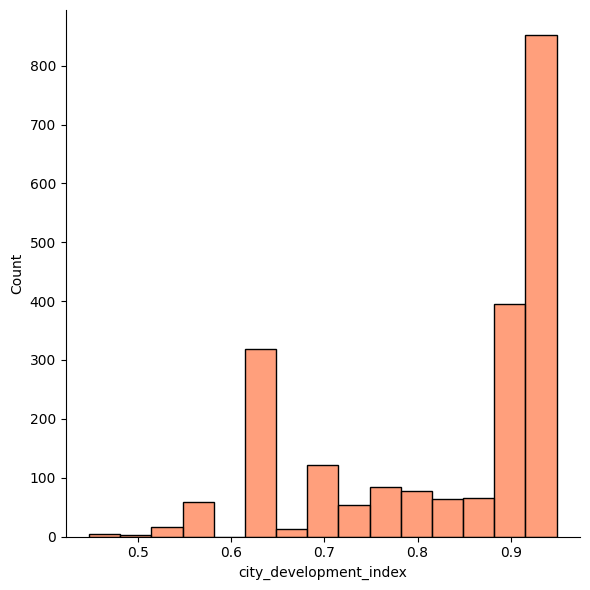

In [21]:
#Distribution city development index - Train

sns.displot(data=df_test, x='city_development_index',height=6,color = 'coral')

## 3.4 Feature *'gender'* - Gender of candidate


In [22]:
gender_train = df_train['gender']
gender_test = df_test['gender']

In [23]:
def percentage(df):

    number = pd.DataFrame(df.value_counts())
    number.columns = ['Total']
    number['%'] = round((number['Total'] / df.notnull().sum())*100,1)
    
    return number

In [24]:
percentage(gender_train)

,Total,%
gender,,
Male,13221,90.2
Female,1238,8.5
Other,191,1.3


In [25]:
percentage(gender_test)

,Total,%
gender,,
Male,1460,90.1
Female,137,8.5
Other,24,1.5


As you can see the% are similar in both datasets

C:\Users\ELZAHBIA\AppData\Local\Temp\ipykernel_33676\3514631317.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


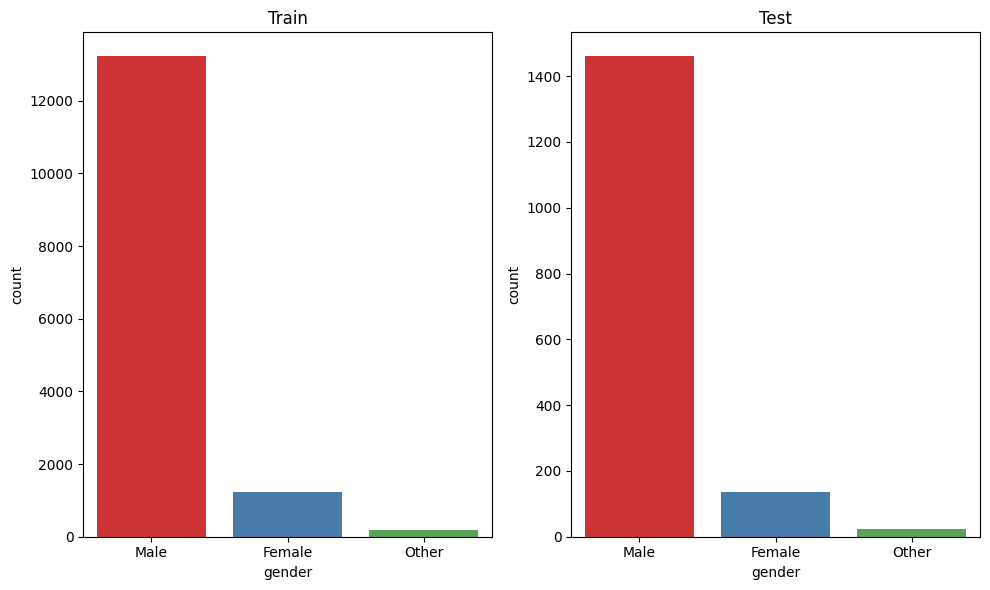

In [26]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

sns.countplot(x="gender",data=df_train,palette="Set1",ax=ax[0]).set_title('Train')
sns.countplot(x="gender",data=df_test,palette="Set1",ax=ax[1]).set_title('Test')
fig.tight_layout()
fig.show()

## 3.5 Feature *'relevent_experience'* - Relevant experience of candidate


In [27]:
relevent_experience_train = df_train['relevent_experience']
relevent_experience_test = df_test['relevent_experience']

In [28]:
percentage(relevent_experience_train)

,Total,%
relevent_experience,,
Has relevent experience,13792,72.0
No relevent experience,5366,28.0


In [29]:
percentage(relevent_experience_test)

,Total,%
relevent_experience,,
Has relevent experience,1524,71.6
No relevent experience,605,28.4


As you can see the% are similar in both datasets

C:\Users\ELZAHBIA\AppData\Local\Temp\ipykernel_33676\865806684.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


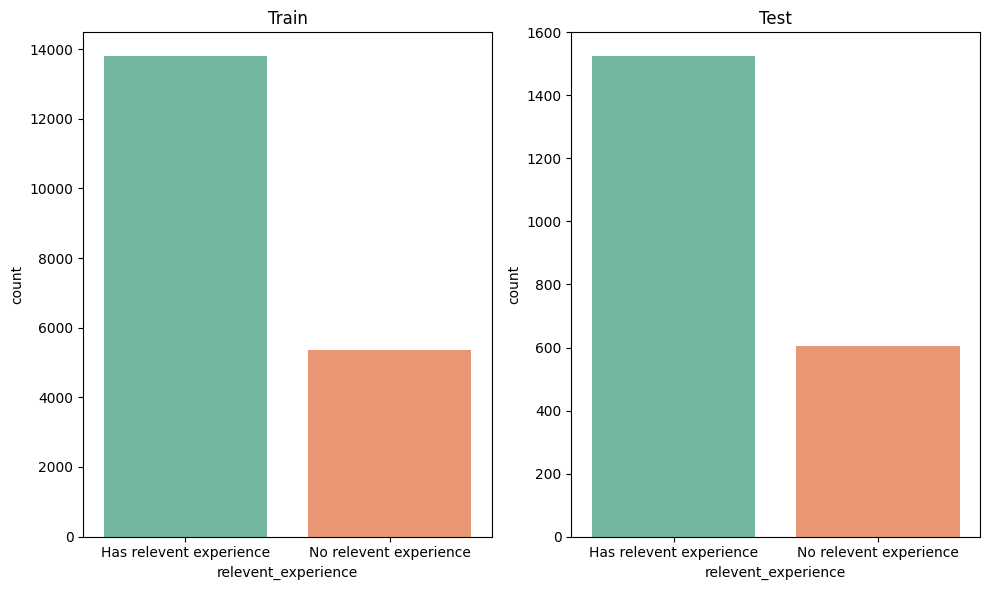

In [30]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

sns.countplot(x='relevent_experience',data=df_train,palette="Set2",ax=ax[0]).set_title('Train')
sns.countplot(x='relevent_experience',data=df_test,palette="Set2",ax=ax[1]).set_title('Test')
fig.tight_layout()
fig.show()

## 3.6 Feature *'enrolled_university'* - Type of University course enrolled if any


In [31]:
enrolled_university_train = df_train['enrolled_university']
enrolled_university_test = df_test['enrolled_university']

In [32]:
percentage(enrolled_university_train)

,Total,%
enrolled_university,,
no_enrollment,13817,73.6
Full time course,3757,20.0
Part time course,1198,6.4


In [33]:
percentage(enrolled_university_test)

,Total,%
enrolled_university,,
no_enrollment,1519,72.4
Full time course,435,20.7
Part time course,144,6.9


In [34]:
order_enrolled_university = percentage(enrolled_university_train).index

As you can see the% are similar in both datasets

C:\Users\ELZAHBIA\AppData\Local\Temp\ipykernel_33676\3300837617.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


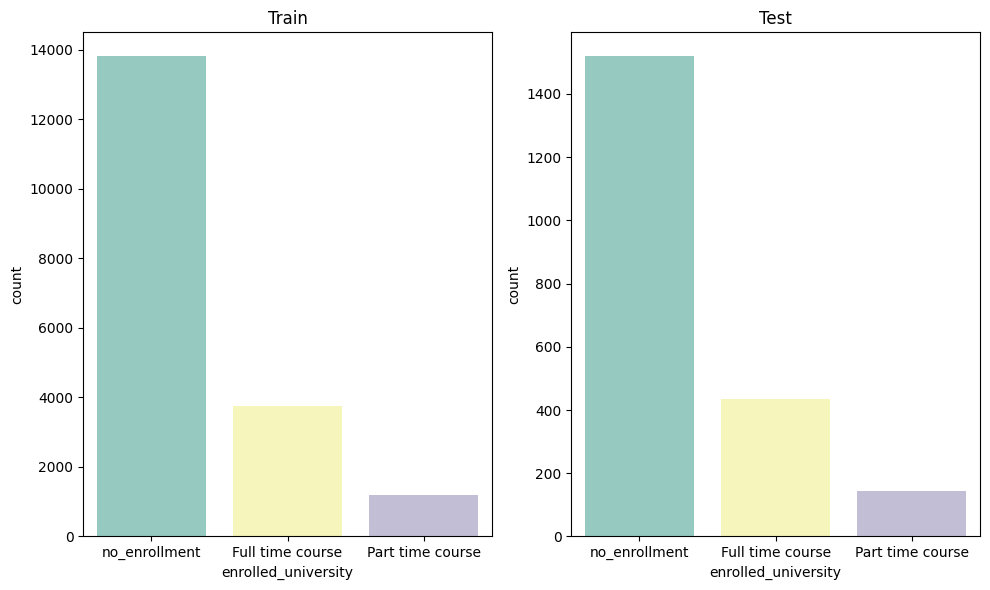

In [35]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

sns.countplot(x='enrolled_university',data=df_train,palette="Set3",ax=ax[0],order=order_enrolled_university).set_title('Train')
sns.countplot(x='enrolled_university',data=df_test,palette="Set3",ax=ax[1],order=order_enrolled_university).set_title('Test')
fig.tight_layout()
fig.show()

## 3.7 Feature *'education_level'* - Education level of candidate


In [36]:
education_level_train = df_train['education_level']
education_level_test = df_test['education_level']

In [37]:
percentage(education_level_train)

,Total,%
education_level,,
Graduate,11598,62.0
Masters,4361,23.3
High School,2017,10.8
Phd,414,2.2
Primary School,308,1.6


In [38]:
percentage(education_level_test)

,Total,%
education_level,,
Graduate,1269,61.1
Masters,496,23.9
High School,222,10.7
Phd,54,2.6
Primary School,36,1.7


As you can see the% are similar in both datasets

In [39]:
order_education_level = percentage(education_level_train).index

C:\Users\ELZAHBIA\AppData\Local\Temp\ipykernel_33676\4247622657.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


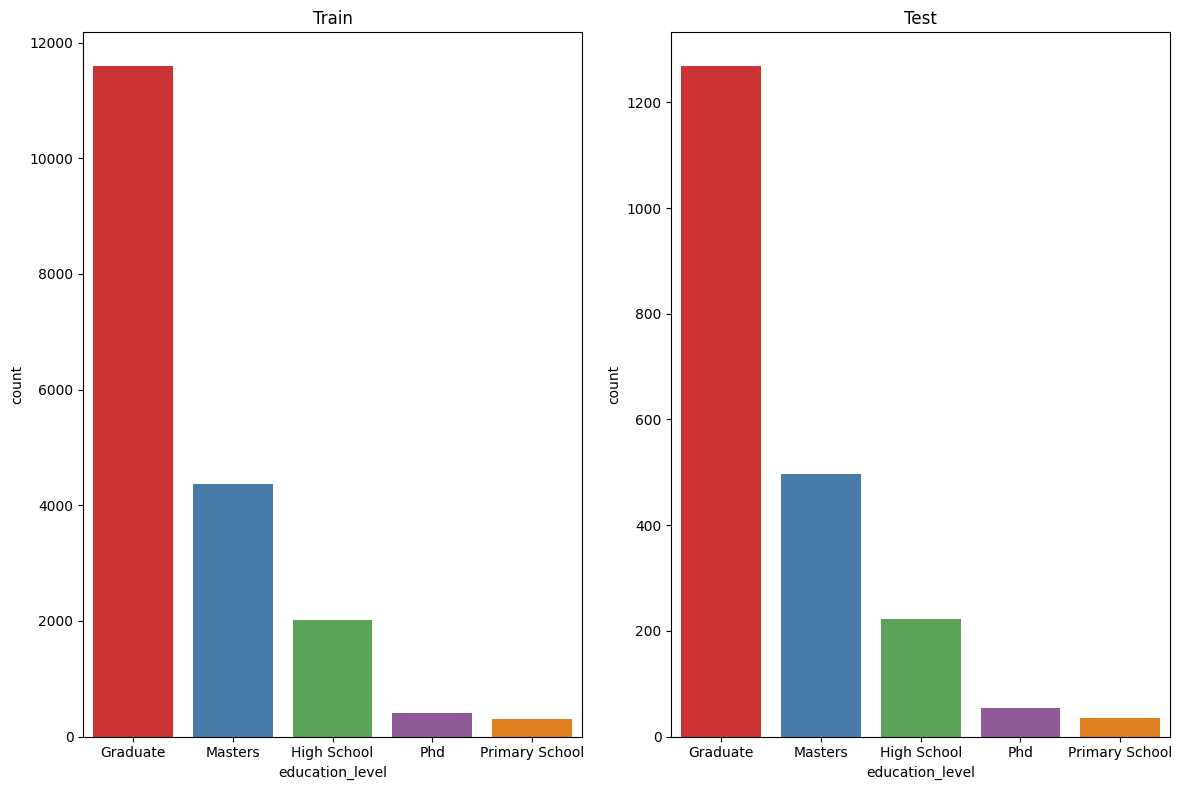

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))

sns.countplot(x='education_level',data=df_train,palette="Set1",ax=ax[0],order=order_education_level).set_title('Train')
sns.countplot(x='education_level',data=df_test,palette="Set1",ax=ax[1],order=order_education_level).set_title('Test')
fig.tight_layout()
fig.show()

## 3.8 Feature *'major_discipline'* - Education major discipline of candidate


In [41]:
major_discipline_train = df_train['major_discipline']
major_discipline_test = df_test['major_discipline']

In [42]:
percentage(major_discipline_train)

,Total,%
major_discipline,,
STEM,14492,88.7
Humanities,669,4.1
Other,381,2.3
Business Degree,327,2.0
Arts,253,1.5
No Major,223,1.4


In [43]:
percentage(major_discipline_test)

,Total,%
major_discipline,,
STEM,1621,89.2
Humanities,80,4.4
Other,40,2.2
Business Degree,37,2.0
No Major,22,1.2
Arts,17,0.9


As you can see the% are similar in both datasets

In [44]:
order_major_discipline = percentage(major_discipline_train).index

C:\Users\ELZAHBIA\AppData\Local\Temp\ipykernel_33676\2950376152.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


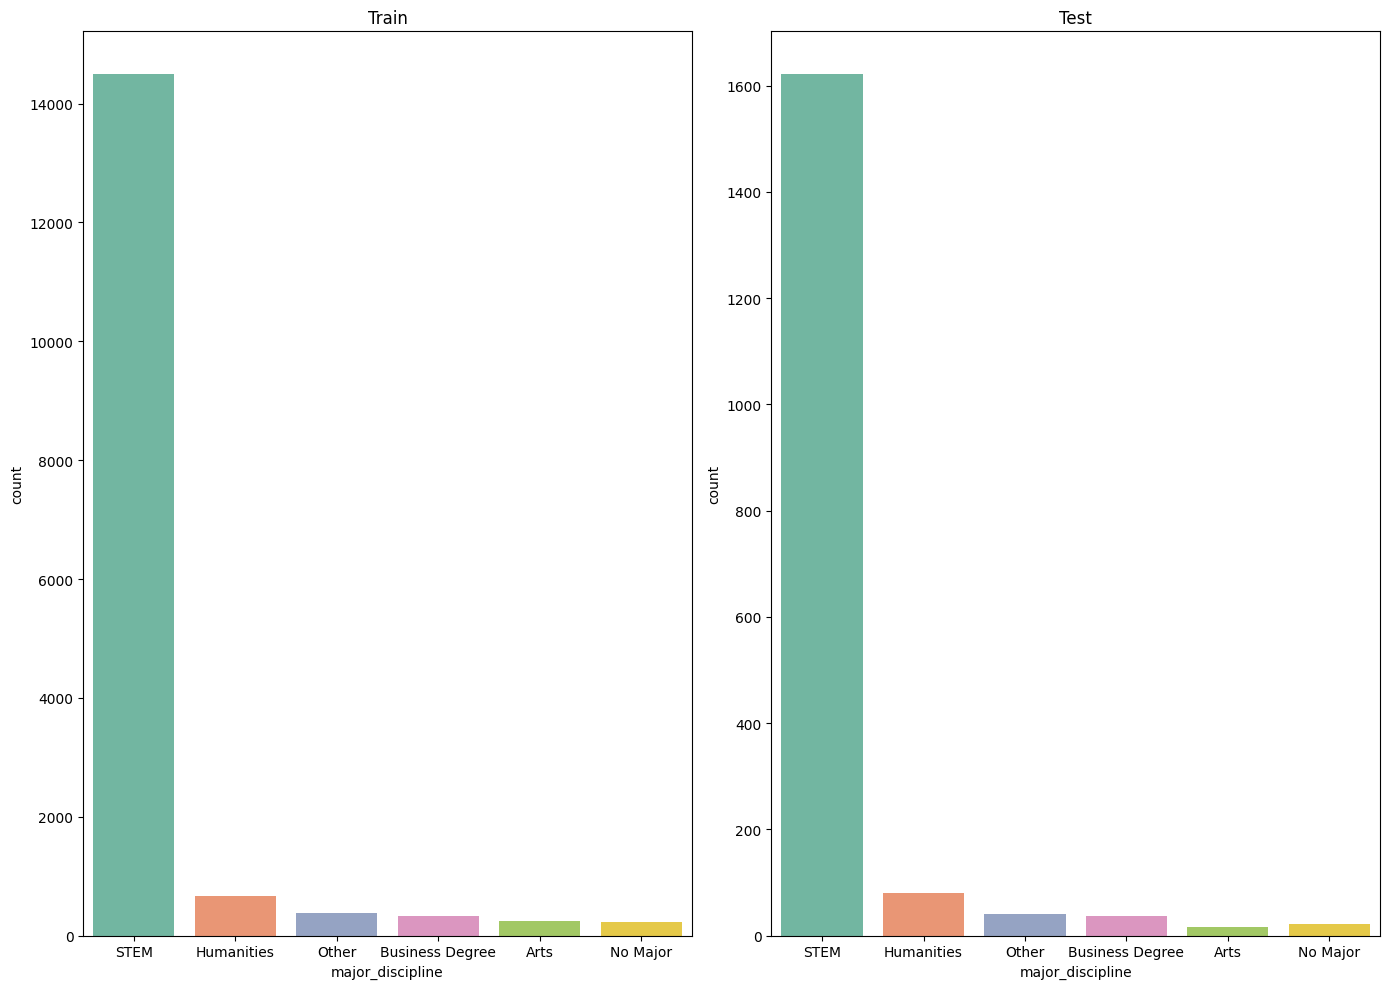

In [45]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 10))

sns.countplot(x='major_discipline',data=df_train,palette="Set2",ax=ax[0],order=order_major_discipline).set_title('Train')
sns.countplot(x='major_discipline',data=df_test,palette="Set2",ax=ax[1],order=order_major_discipline).set_title('Test')
fig.tight_layout()
fig.show()

## 3.9 Feature *'experience'* - Candidate total experience in years


In [46]:
experience_train = df_train['experience']
experience_test = df_test['experience']

In [47]:
percentage(experience_train)

,Total,%
experience,,
>20,3286,17.2
5,1430,7.5
4,1403,7.3
3,1354,7.1
6,1216,6.4
2,1127,5.9
7,1028,5.4
10,985,5.2
9,980,5.1


In [48]:
percentage(experience_test)

,Total,%
experience,,
>20,383,18.0
5,163,7.7
3,154,7.3
4,145,6.8
6,130,6.1
2,128,6.0
7,116,5.5
9,113,5.3
10,96,4.5


In [49]:
order_experience = percentage(experience_train).index

C:\Users\ELZAHBIA\AppData\Local\Temp\ipykernel_33676\15416189.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


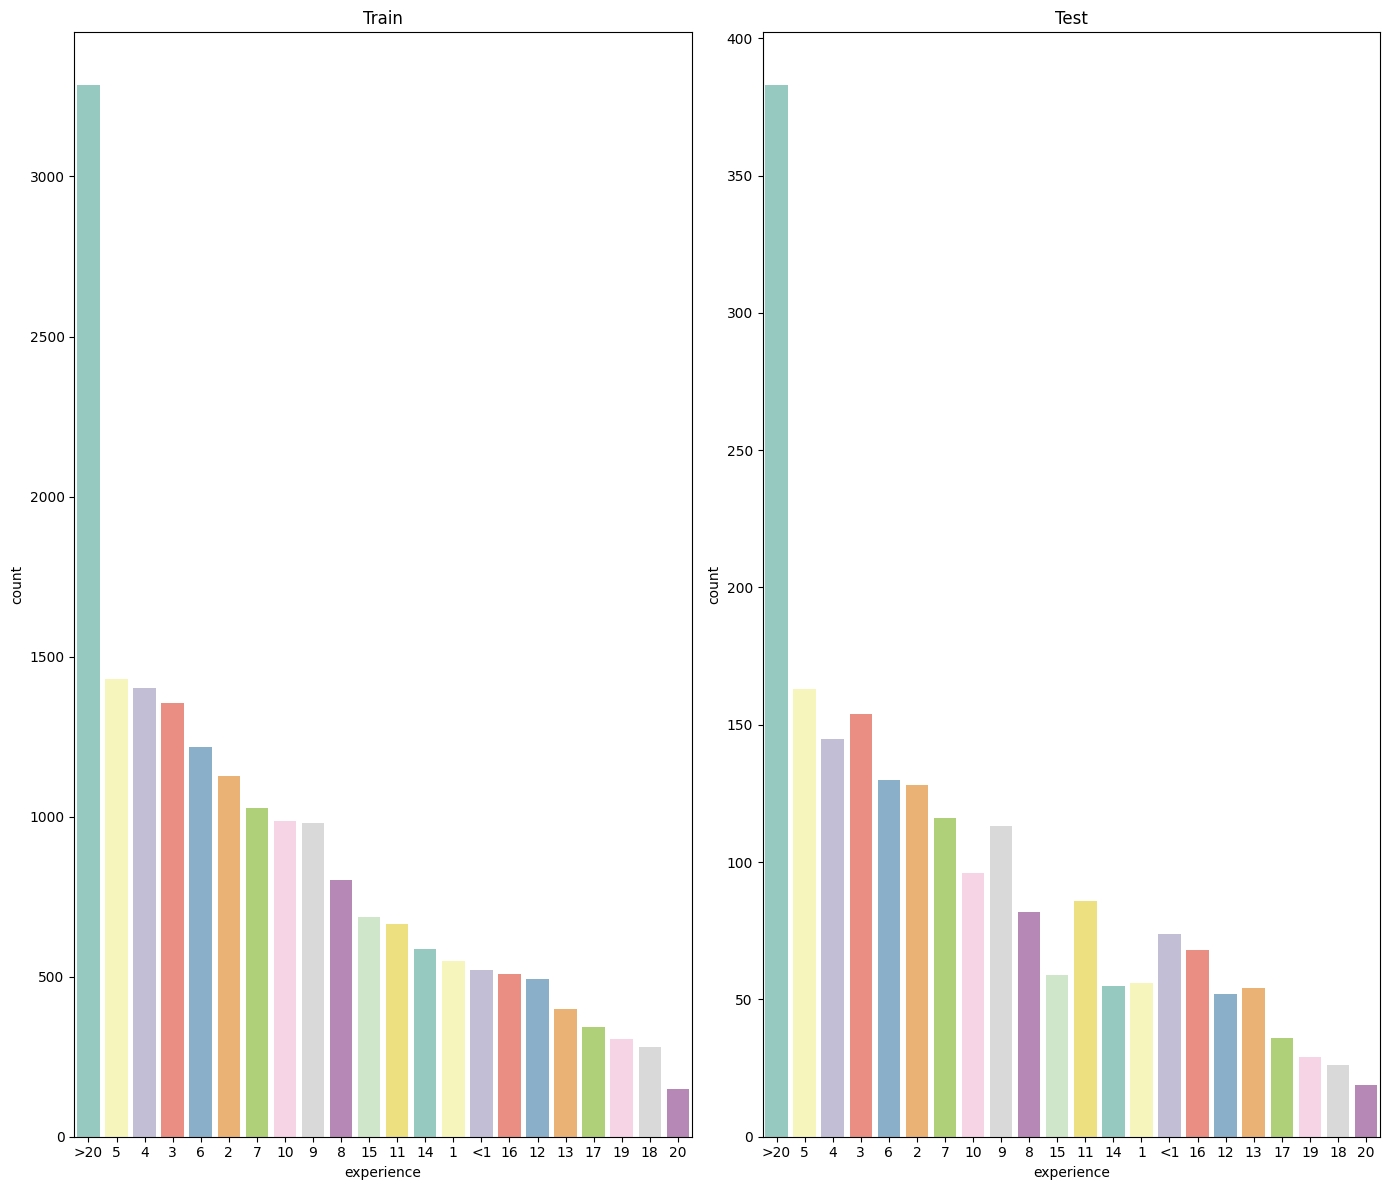

In [50]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 12))

sns.countplot(x='experience',data=df_train,palette="Set3",ax=ax[0],order=order_experience).set_title('Train')
sns.countplot(x='experience',data=df_test,palette="Set3",ax=ax[1],order=order_experience).set_title('Test')
fig.tight_layout()
fig.show()

## 3.10 Feature *'company_size'* - No of employees in current employer's company

In [51]:
company_size_train = df_train['company_size']
company_size_test = df_test['company_size']

In [52]:
percentage(company_size_train)

,Total,%
company_size,,
50-99,3083,23.3
100-500,2571,19.4
10000+,2019,15.3
10/49,1471,11.1
1000-4999,1328,10.0
<10,1308,9.9
500-999,877,6.6
5000-9999,563,4.3


In [53]:
percentage(company_size_test)

,Total,%
company_size,,
50-99,338,22.4
100-500,318,21.1
10000+,217,14.4
10/49,172,11.4
<10,163,10.8
1000-4999,143,9.5
500-999,88,5.8
5000-9999,68,4.5


As you can see the% are similar in both datasets

In [54]:
order_company_size = percentage(company_size_train).index

C:\Users\ELZAHBIA\AppData\Local\Temp\ipykernel_33676\2747365416.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


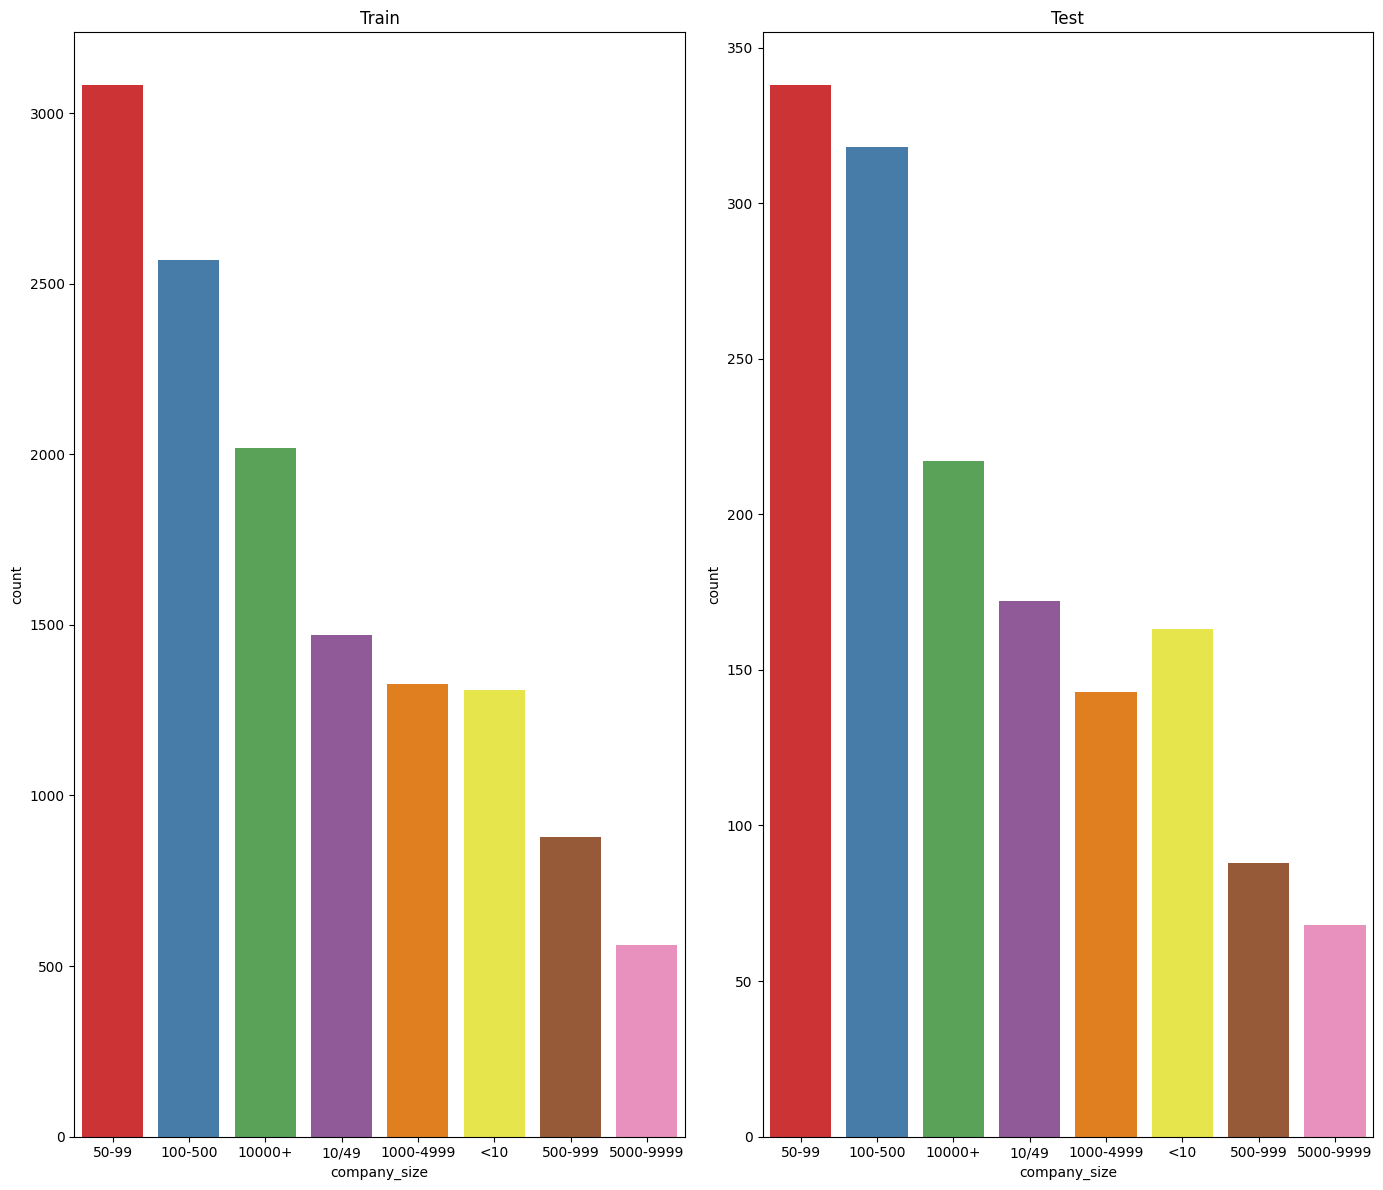

In [55]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 12))

sns.countplot(x='company_size',data=df_train,palette="Set1",ax=ax[0],order=order_company_size).set_title('Train')
sns.countplot(x='company_size',data=df_test,palette="Set1",ax=ax[1],order=order_company_size).set_title('Test')
fig.tight_layout()
fig.show()

## 3.11 Feature *'company_type'* - Type of current employer

In [56]:
company_type_train = df_train['company_type']
company_type_test = df_test['company_type']

In [57]:
percentage(company_type_train)

,Total,%
company_type,,
Pvt Ltd,9817,75.4
Funded Startup,1001,7.7
Public Sector,955,7.3
Early Stage Startup,603,4.6
NGO,521,4.0
Other,121,0.9


In [58]:
percentage(company_type_test)

,Total,%
company_type,,
Pvt Ltd,1141,76.3
Public Sector,127,8.5
Funded Startup,97,6.5
Early Stage Startup,65,4.3
NGO,53,3.5
Other,12,0.8


As you can see the% are similar in both datasets

In [59]:
order_company_type = percentage(company_type_train).index

C:\Users\ELZAHBIA\AppData\Local\Temp\ipykernel_33676\1762253980.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


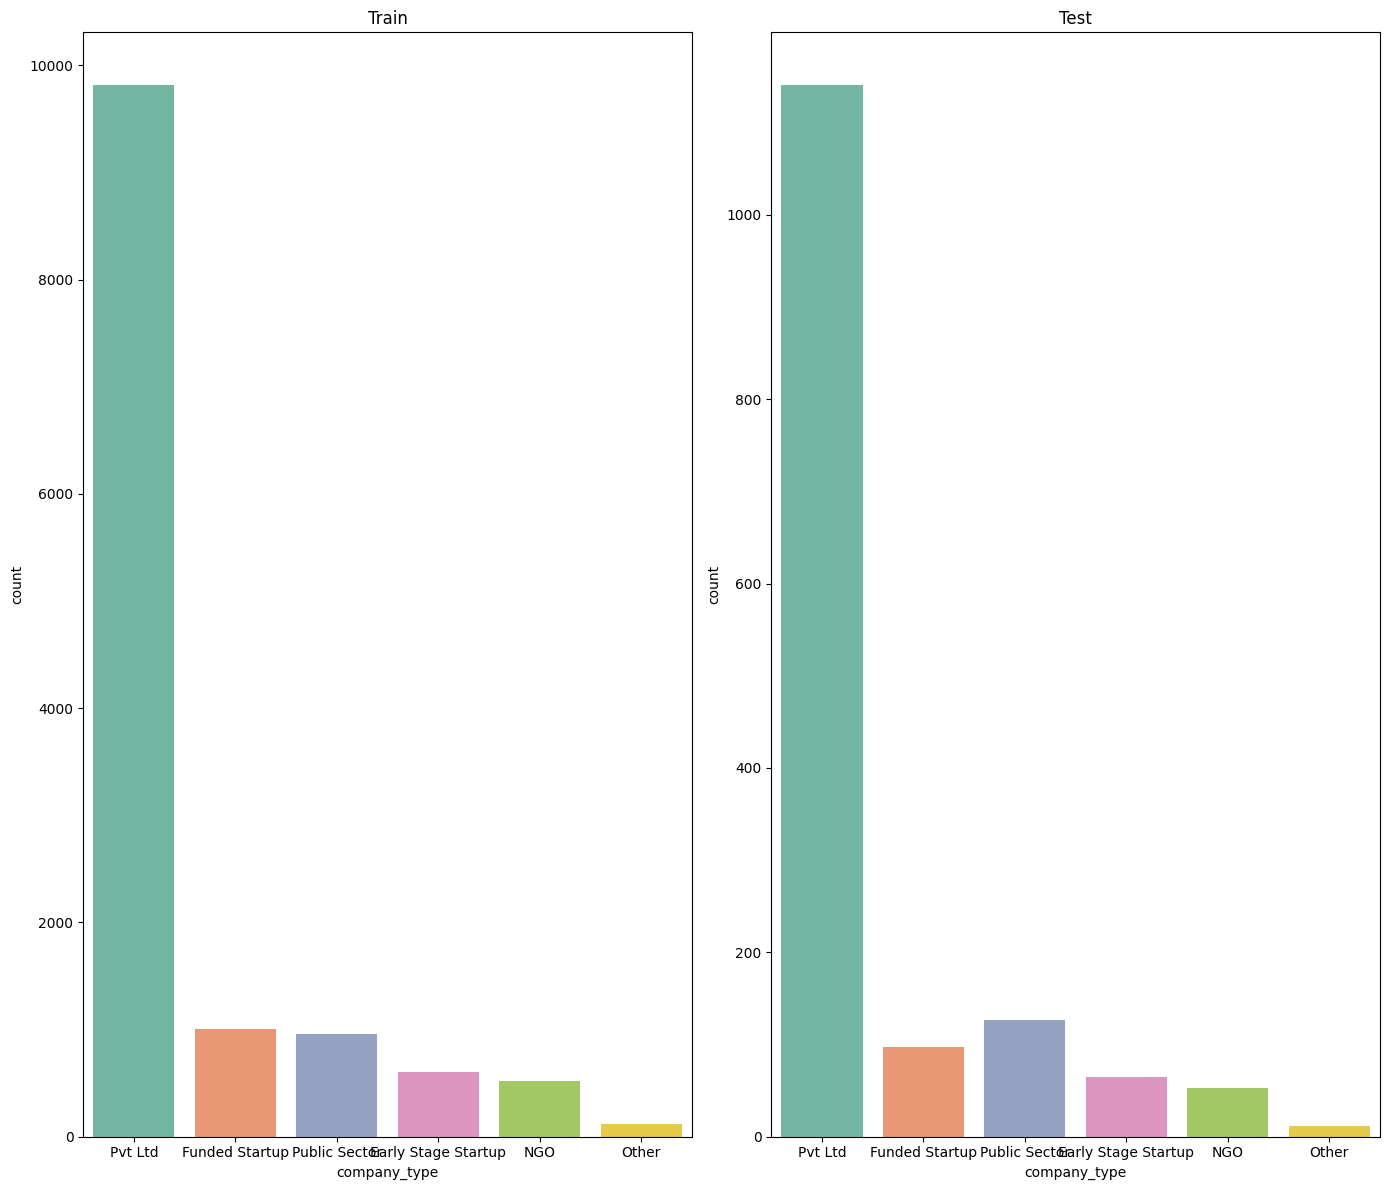

In [60]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 12))

sns.countplot(x='company_type',data=df_train,palette="Set2",ax=ax[0],order=order_company_type).set_title('Train')
sns.countplot(x='company_type',data=df_test,palette="Set2",ax=ax[1],order=order_company_type).set_title('Test')
fig.tight_layout()
fig.show()

## 3.12 Feature *'lastnewjob'* - Difference in years between previous job and current job

In [61]:
last_new_job_train = df_train['last_new_job']
last_new_job_test = df_test['last_new_job']

In [62]:
percentage(last_new_job_train)

,Total,%
last_new_job,,
1,8040,42.9
>4,3290,17.6
2,2900,15.5
never,2452,13.1
4,1029,5.5
3,1024,5.5


In [63]:
percentage(last_new_job_test)

,Total,%
last_new_job,,
1,884,42.3
>4,353,16.9
2,342,16.4
never,258,12.4
3,133,6.4
4,119,5.7


As you can see the% are similar in both datasets

In [64]:
order_last_new_job = percentage(last_new_job_train).index

C:\Users\ELZAHBIA\AppData\Local\Temp\ipykernel_33676\606730539.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


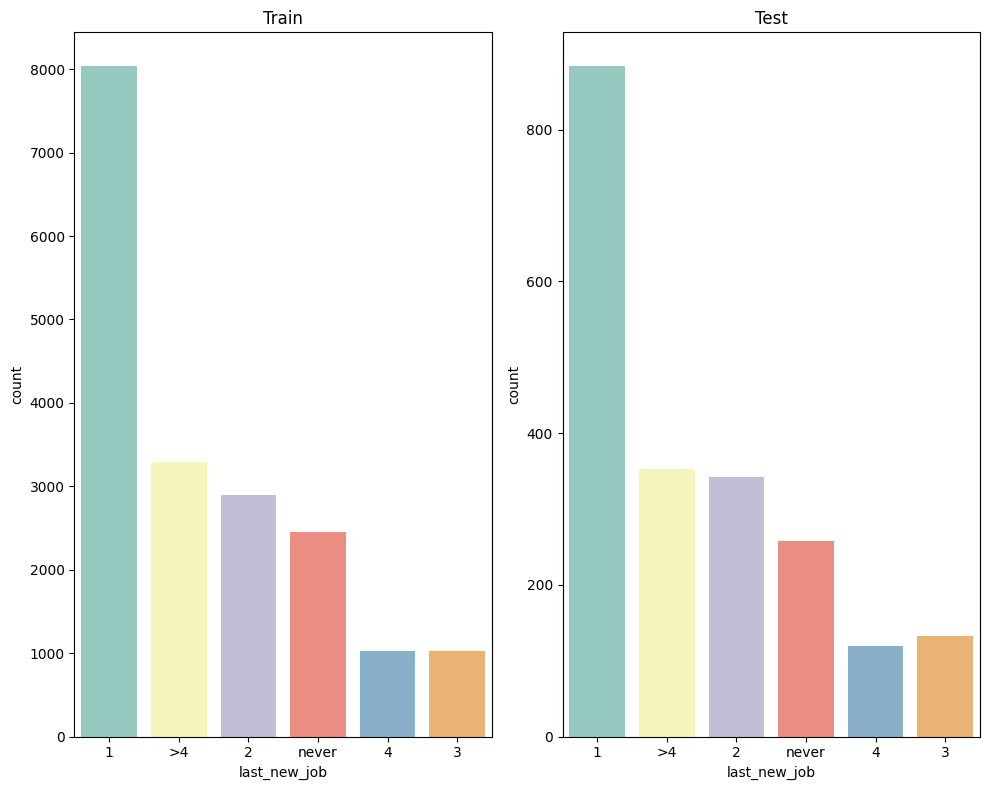

In [65]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))

sns.countplot(x='last_new_job',data=df_train,palette="Set3",ax=ax[0],order=order_last_new_job).set_title('Train')
sns.countplot(x='last_new_job',data=df_test,palette="Set3",ax=ax[1],order=order_last_new_job).set_title('Test')
fig.tight_layout()
fig.show()

## 3.13 Feature *'training_hours'* - Training hours completed

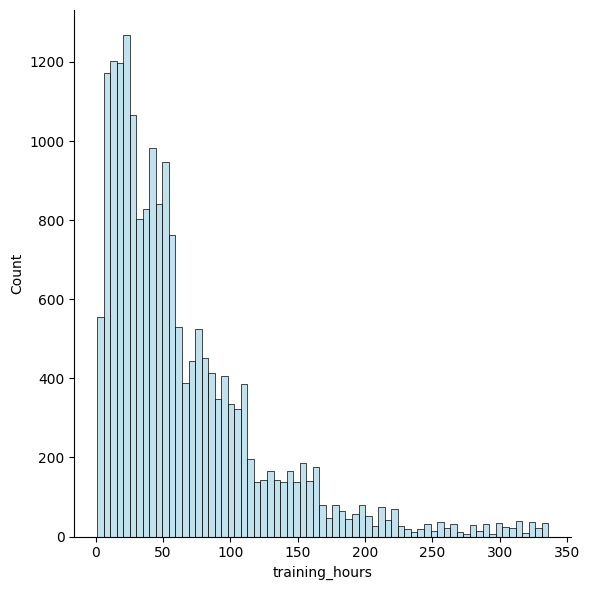

In [66]:
#Distribution of training hours - Train

sns.displot(data=df_train, x='training_hours',height=6,color = 'lightblue')

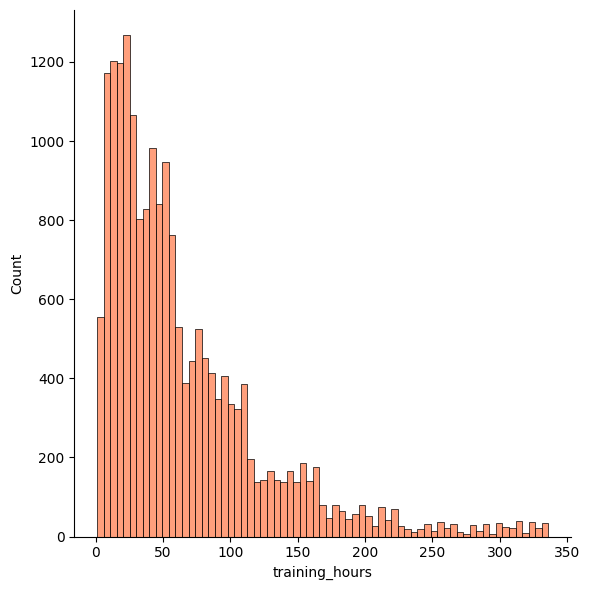

In [67]:
#Distribution of training hours - Test

sns.displot(data=df_train, x='training_hours',height=6,color = 'coral')

## 3.14 *'Target'* 

     0 - Not looking for job change
     1 - Looking for a job change

In [68]:
target = df_train['target']

In [69]:
percentage(target)

,Total,%
target,,
0.0,14381,75.1
1.0,4777,24.9


Text(0.5, 1.0, 'Train')

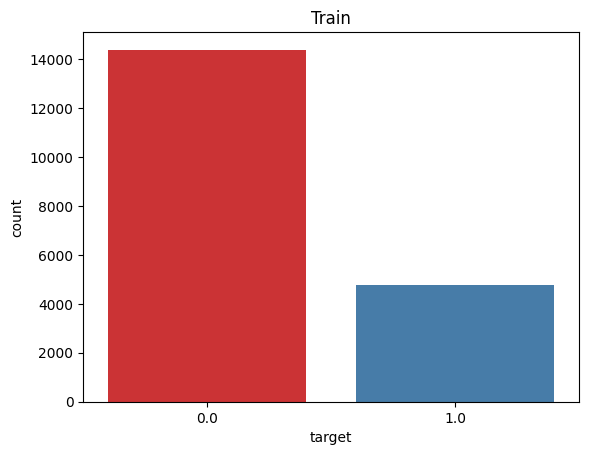

In [70]:
sns.countplot(x='target',data=df_train,palette="Set1").set_title('Train')

### Target by city development index

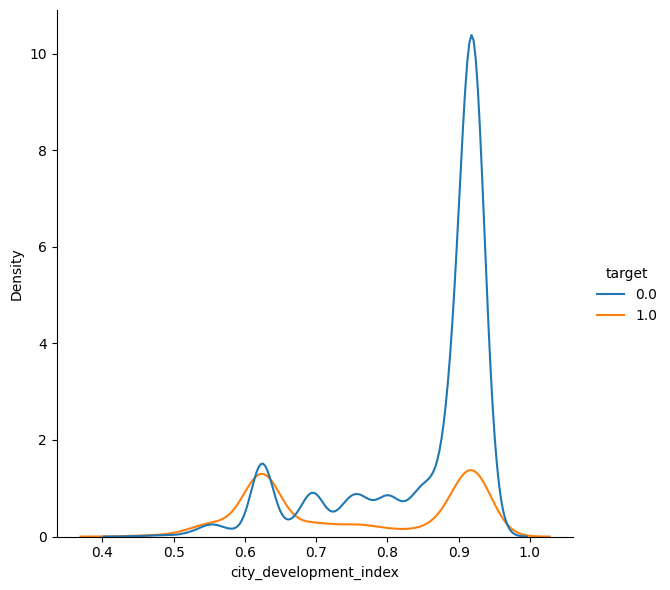

In [71]:
#Distribution

sns.displot(data=df_train, x='city_development_index', hue='target',kind='kde',height=6)

### Target by gender

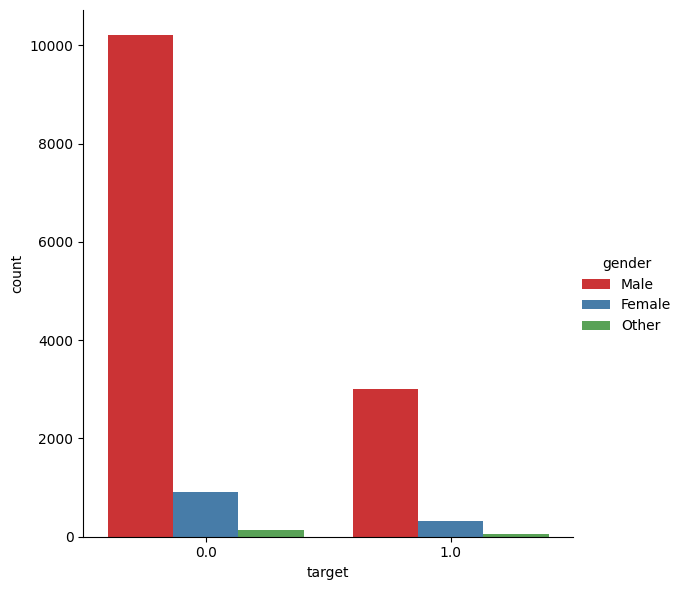

In [72]:
sns.catplot(x="target",hue='gender',data=df_train,palette="Set1",kind="count",height=6)

### Target by relevant experience

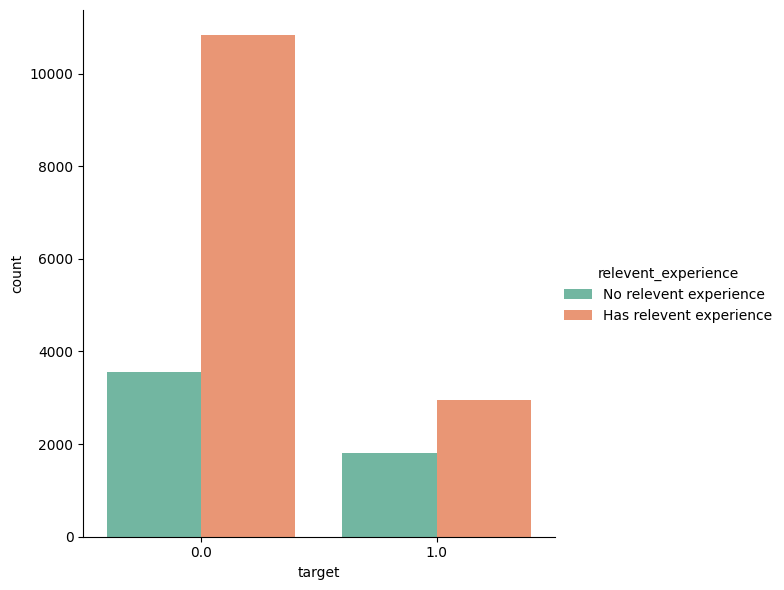

In [73]:
sns.catplot(x="target",hue='relevent_experience',data=df_train,palette="Set2",kind="count",height=6)

### Target by enrolled university

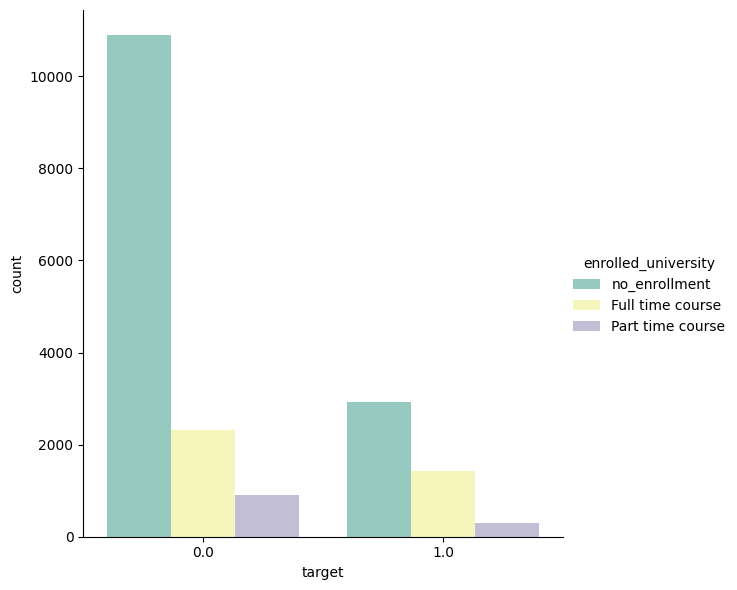

In [74]:
sns.catplot(x="target",hue='enrolled_university',data=df_train,palette="Set3",kind="count",height=6)

### Target by education level

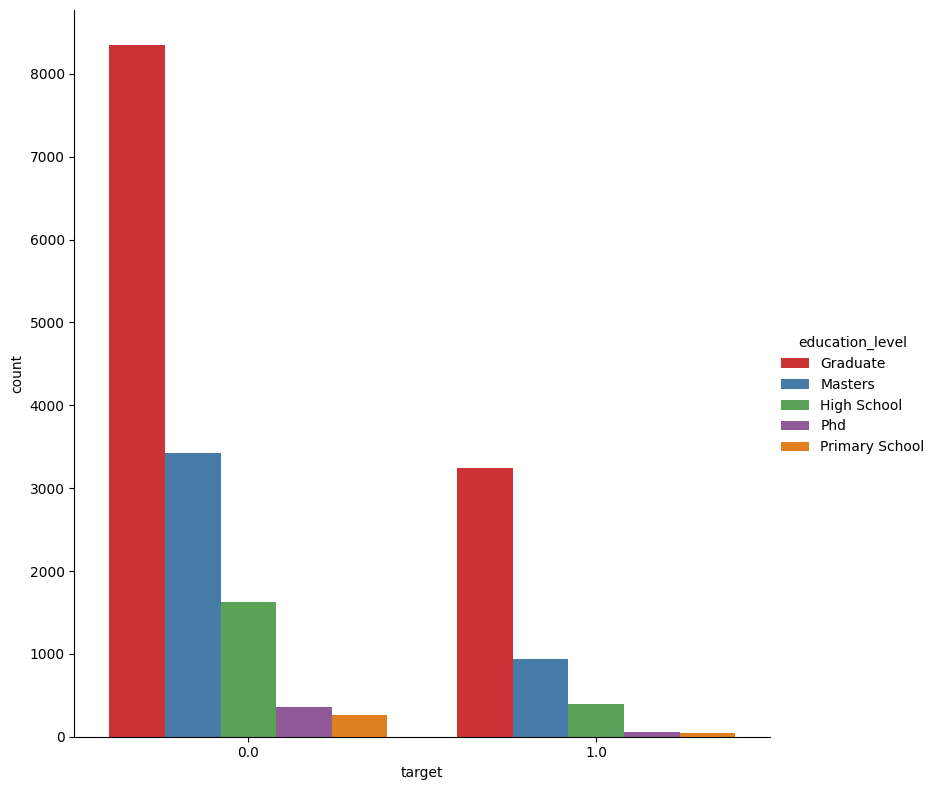

In [75]:
sns.catplot(x="target",hue='education_level',data=df_train,palette="Set1",kind="count",height=8) 

### Target by major discipline

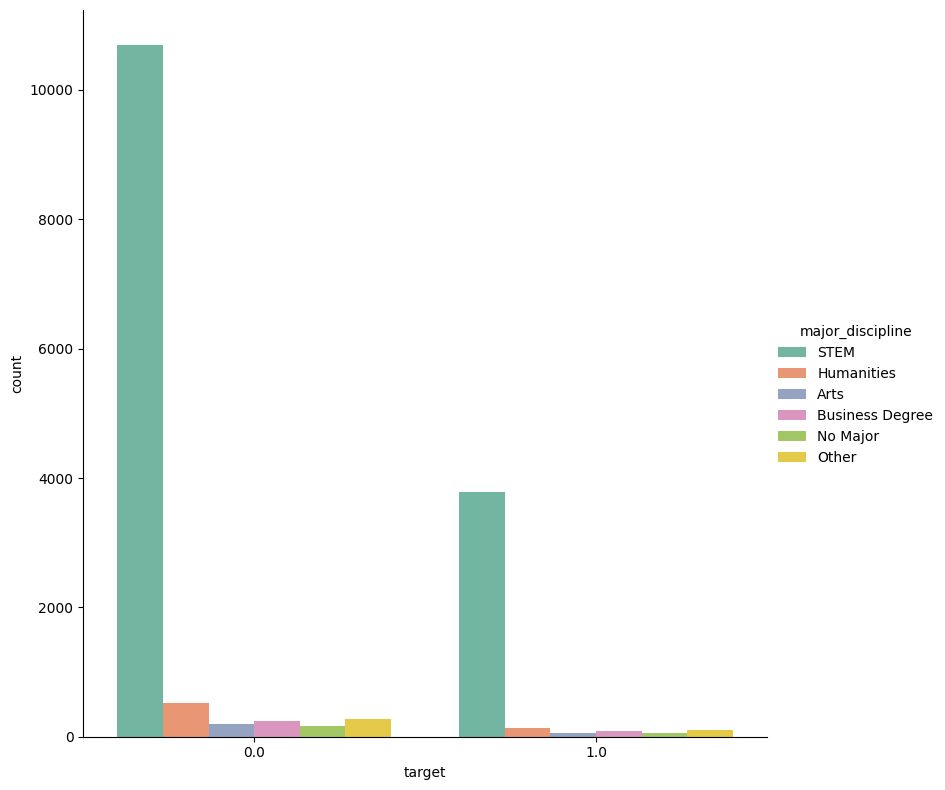

In [76]:
sns.catplot(x="target",hue='major_discipline',data=df_train,palette="Set2",kind="count",height=8)

### Target by major experience

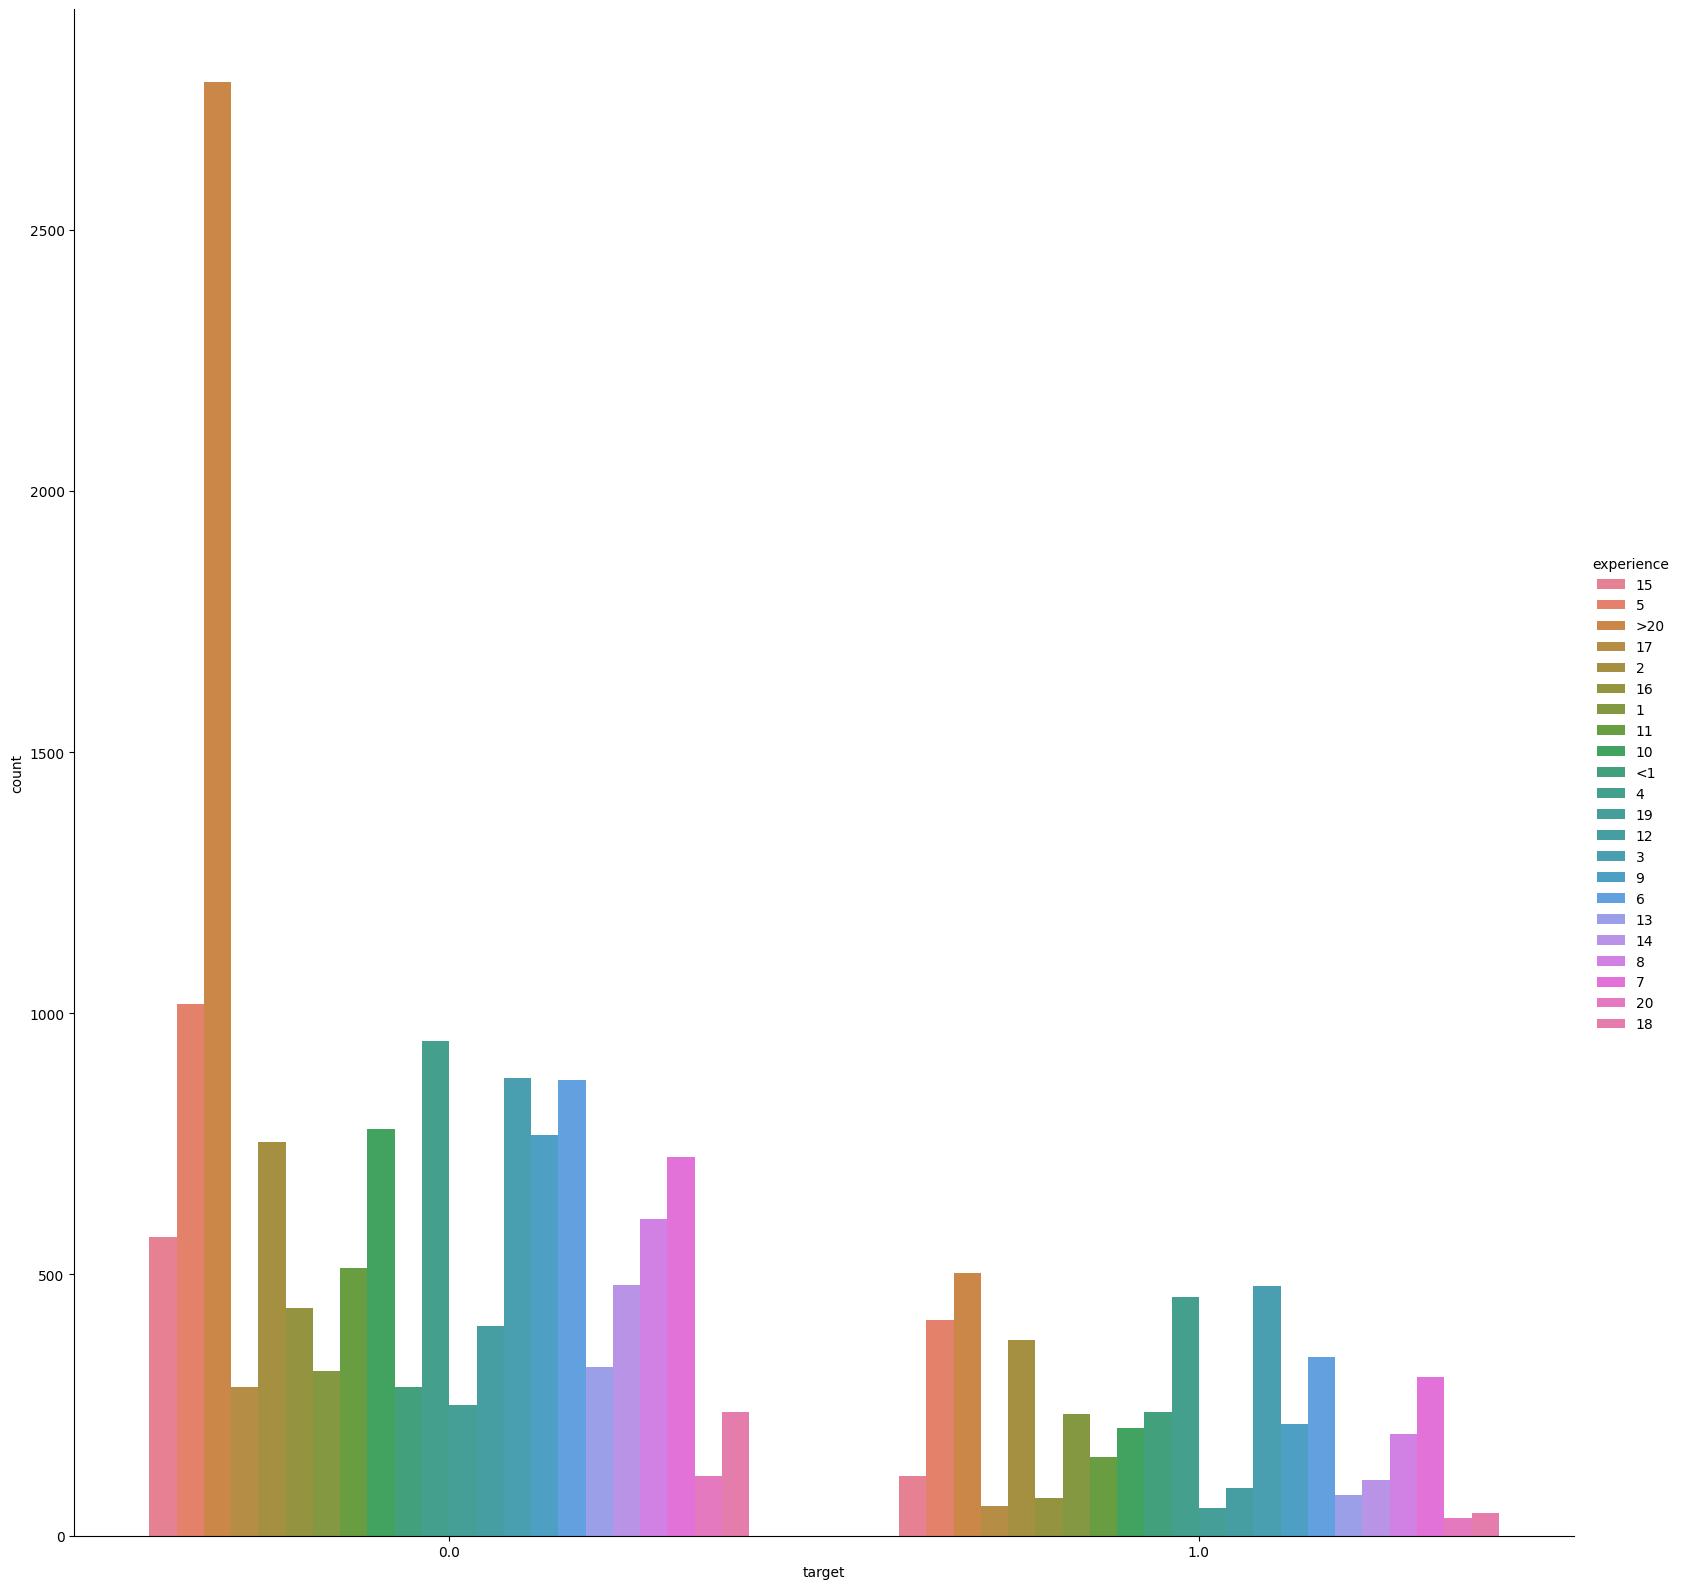

In [77]:
sns.catplot(x="target",hue='experience',data=df_train,kind="count",height=16)

### Target by training hours

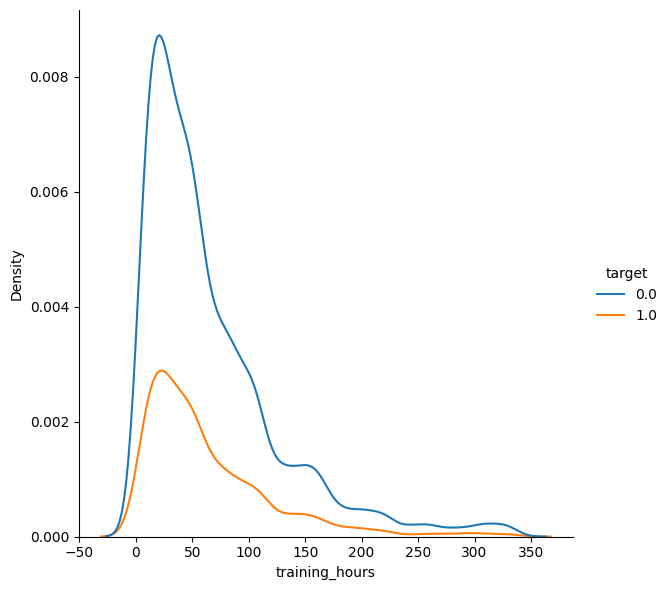

In [78]:
#Distribution

sns.displot(data=df_train, x='training_hours', hue='target',kind='kde',height=6)